## YOLO = You Only Look Once

YoloV8 is the latest version of this object detection algorithm and it has 5 categories of models: YOLOv8n,	YOLOv8s,	YOLOv8m,	YOLOv8l,	YOLOv8x. YOLOv8n is the fastest and YOLOv8x is the slowest but most accurate

- YoloV8 can perform detection, classification and segmentation tasks on images and videos.
- YoloV8 was developed using Pytorch and can be executed in both CPUs and GPUs.

Selecione GPU do colab para executar o YoloV8.

In [1]:
## Installing ultralytics to use YoloV8 - https://docs.ultralytics.com/
!pip install ultralytics

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
import torch
if torch.cuda.is_available():
  print('GPU is available')
else:
  print("GPU is not available")

GPU is available


In [3]:
import cv2
from ultralytics import YOLO

1. Photo by Александр Македонский from <a href="https://www.pexels.com/photo/dogs-on-road-3581058/">Pexels</a> 
2. Video by <a href="https://pixabay.com/users/mikes-photography-1860391/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=video&amp;utm_content=2165">Mikes-Photography</a> from <a href="https://pixabay.com//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=video&amp;utm_content=2165">Pixabay</a>

In [4]:
# insert image and video in the colab project
image = '/content/image.jpg'
video = '/content/car-2165.mp4'

In [5]:
# load a pretrained model for detection
yolo = YOLO('yolov8n.pt') 

## Object Detection

List of arguments to be passed to predict: https://docs.ultralytics.com/modes/predict/#arguments

Some examples are: 
- **save** which saves the results;
- **save_txt** which save the results as txt files; 
- **save_crop** which save the detected objects as cropped, etc.
- **conf** which specifies the object confidence threshold for detection. Default it's 0.25



In [6]:
results = yolo.predict(image, conf=0.30)
# for result in results:
# boxes = result.boxes  # object with properties and methods for manipulating bounding boxes
# masks = result.masks  # object for indexing masks or getting segment coordinates
# probs = result.probs  # Class probabilities for classification outputs


image 1/1 /content/image.jpg: 640x640 5 persons, 8 cars, 8 dogs, 2 cows, 7.7ms
Speed: 3.5ms preprocess, 7.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


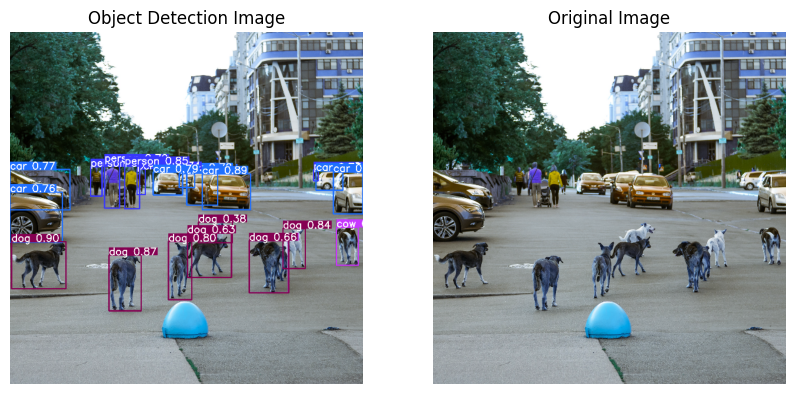

In [7]:
# to show the image, I can use the plot method since it plots all 
# components(boxes, masks, classification logits, etc.) 
# found in the results object
import matplotlib.pyplot as plt

res_plotted = results[0].plot()

resized_img = cv2.resize(res_plotted, (600, 600)) 
resized_original_img = cv2.resize(results[0].orig_img, (600, 600))

plt.figure(figsize=(10, 10))

# 1 row, 2 cols
ax = plt.subplot(1, 2, 1) 
plt.imshow(resized_img)
plt.title('Object Detection Image')
plt.axis("off")

ax = plt.subplot(1, 2, 2)
plt.imshow(resized_original_img)
plt.title('Original Image')
plt.axis("off")

plt.show()

In [8]:
from google.colab.patches import cv2_imshow

v_results = yolo.predict(video, save=True)



    WARNING ⚠️ stream/video/webcam/dir predict source will accumulate results in RAM unless `stream=True` is passed,
    causing potential out-of-memory errors for large sources or long-running streams/videos.

    Usage:
        results = model(source=..., stream=True)  # generator of Results objects
        for r in results:
            boxes = r.boxes  # Boxes object for bbox outputs
            masks = r.masks  # Masks object for segment masks outputs
            probs = r.probs  # Class probabilities for classification outputs

video 1/1 (1/1501) /content/car-2165.mp4: 384x640 11 cars, 70.8ms
video 1/1 (2/1501) /content/car-2165.mp4: 384x640 10 cars, 7.0ms
video 1/1 (3/1501) /content/car-2165.mp4: 384x640 11 cars, 7.6ms
video 1/1 (4/1501) /content/car-2165.mp4: 384x640 11 cars, 6.0ms
video 1/1 (5/1501) /content/car-2165.mp4: 384x640 11 cars, 7.2ms
video 1/1 (6/1501) /content/car-2165.mp4: 384x640 10 cars, 5.8ms
video 1/1 (7/1501) /content/car-2165.mp4: 384x640 10 cars, 7.9ms
vid

In [9]:
from IPython.display import HTML
from base64 import b64encode
import os

def display_video(input, output):
  # ffmpeg = video and audio processing tool
  # -i path = input file
  # -vcodec libx264 = algorithm to compress video using H.264 algorithm
  # compressed_path = output path
  os.system(f"ffmpeg -i {input} -vcodec libx264 {output}")

  video_data = open(output, "rb").read()
  video_encoded = b64encode(video_data).decode("ascii")

  return f'<video width="600" controls><source src="data:video/mp4;base64,{video_encoded}" type="video/mp4"></video>'

In [10]:
v_result_path = '/content/runs/detect/predict2/car-2165.mp4'
compressed_path = '/content/runs/detect/predict2/car-2165_compressed.mp4'

# Display the video in Colab
HTML(data=display_video(v_result_path, compressed_path))

## Object Segmentation

List of arguments to be passed to predict: https://docs.ultralytics.com/modes/predict/#arguments

Some examples are: 
- **save** which saves the results;
- **save_txt** which save the results as txt files; 
- **save_crop** which save the detected objects as cropped, etc.
- **conf** which specifies the object confidence threshold for detection. Default it's 0.25



In [11]:
# loading pre-trained model for segmentation
yolo_seg = YOLO('yolov8n-seg.pt')

In [12]:
seg_results = yolo_seg.predict(image)


image 1/1 /content/image.jpg: 640x640 4 persons, 9 cars, 7 dogs, 1 cow, 9.9ms
Speed: 3.3ms preprocess, 9.9ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


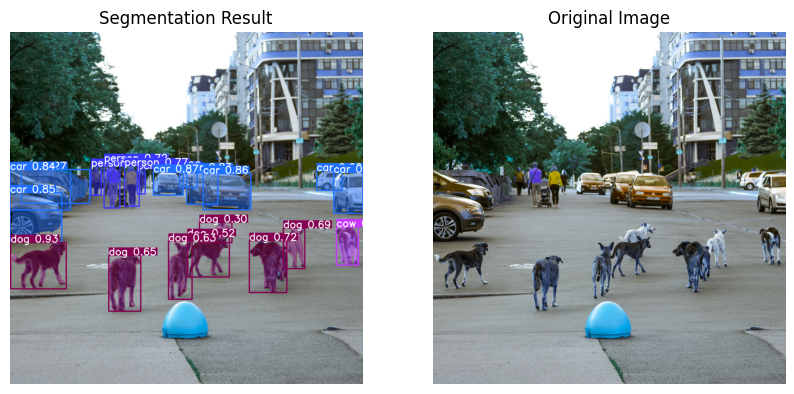

In [13]:
plt.figure(figsize=(10, 10))

seg_results_plot = seg_results[0].plot()
seg_original_img = seg_results[0].orig_img

plt.subplot(1, 2, 1)
plt.imshow(seg_results_plot)
plt.title('Segmentation Result')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(seg_original_img)
plt.title('Original Image')
plt.axis('off')

plt.show()